# 02 - K-Means Manhattan

Clustering dengan **K-Means** memakai jarak Manhattan. Jumlah klaster `k`
ditentukan dengan **Elbow Method**. PCA 2D dipakai **hanya untuk visualisasi**.

## Alur

```
X_scaled
   ↓  elbow: coba k = 1..10
k optimal
   ↓  K-Means
label klaster  →  PCA 2D  →  scatter + pusat klaster
```

## Rumus Jarak

$$d_{euclid}(x,y)=\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}\qquad
d_{manhattan}(x,y)=\sum_{i=1}^{n}|x_i-y_i|$$

$$\cos(x,y)=\frac{x\cdot y}{\lVert x\rVert\,\lVert y\rVert},\qquad
d_{cosine}(x,y)=1-\cos(x,y)$$

## Rumus K-Means

$$J=\sum_{k=1}^{K}\sum_{x\in S_k} d(x,\mu_k)$$

Pusat klaster $\mu_k$: Euclidean -> **mean**, Manhattan -> **median**,
Cosine -> **mean ternormalisasi** (spherical K-Means).

## Rumus Elbow

Cari `k` yang titiknya paling jauh dari garis lurus antara `k` pertama dan
`k` terakhir pada kurva nilai objektif.

## Rumus Evaluasi

Silhouette: $s=\frac{b-a}{\max(a,b)}$ (makin dekat 1 makin baik).

## 0. Import & Muat Data

In [1]:
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.metrics import (pairwise_distances, silhouette_score,
                             davies_bouldin_score, calinski_harabasz_score)

folder = 'Clustering_Stok'
LABEL = {'euclidean': 'Euclidean (L2)', 'manhattan': 'Manhattan (L1)', 'cosine': 'Cosine'}

In [2]:
X_df = pd.read_csv(f'{folder}/X_scaled.csv')
fitur = json.load(open(f'{folder}/meta.json'))['features']
X = X_df[fitur].values
data_asli = pd.read_csv(f'{folder}/fitur_produk_outlet.csv')
print('Jumlah produk-outlet :', X.shape[0])
print('Jumlah fitur         :', X.shape[1])

Jumlah produk-outlet : 282
Jumlah fitur         : 9


In [3]:
X_df.head()

,Outlet,Item,mean_daily,max_daily,trend_weekly_pct,weekend_ratio,momentum_30d,share_morning,share_evening,loyalty_share,avg_price
0,SHOP001,Air Mineral,1.322714,0.672432,-0.974961,-0.109107,-0.461093,0.166549,0.793543,-1.130617,-2.680986
1,SHOP001,Americano (Hot Arabica),1.511247,1.625325,-0.227430,0.609017,0.319884,0.107841,-0.430186,-1.130617,-0.305002
2,SHOP001,Americano (Hot Houseblend),0.782254,1.625325,-0.045790,0.579206,-0.298570,0.727303,0.343123,-1.130617,-0.305002
3,SHOP001,Americano (Ice Arabica),1.234732,0.672432,-0.884758,0.891666,-0.662410,0.501842,-0.654609,-1.130617,-0.305002
4,SHOP001,Americano (Ice Houseblend),1.372989,0.672432,-0.628443,-0.213534,0.060751,0.818590,-0.933467,-1.130617,-0.305002


## 1. Fungsi Bantu

- `kmeans`: K-Means sederhana (pusat = mean / median / mean ternormalisasi).
- `cari_k_optimal`: titik siku elbow.
- `elbow`: gambar kurva elbow untuk satu metrik, mengembalikan `k` optimal.
- `jalankan`: jalankan K-Means, evaluasi, simpan hasil.
- `plot_pca`: scatter 2D + pusat klaster (PCA hanya untuk gambar).

In [4]:
def kmeans(data, k, metric, seed=42):
    rng = np.random.RandomState(seed)
    pusat = data[rng.choice(len(data), k, replace=False)]      # 1. pusat awal acak
    label = None

    for iterasi in range(1, 101):
        jarak = pairwise_distances(data, pusat, metric=metric) # 2. jarak ke tiap pusat
        label_baru = jarak.argmin(axis=1)                      # 3. ikut pusat terdekat
        if label is not None and (label_baru == label).all():  # selesai bila label tetap
            break
        label = label_baru
        for i in range(k):                                     # 4. hitung pusat baru
            anggota = data[label == i]
            if len(anggota) > 0:
                if metric == 'manhattan':
                    pusat[i] = np.median(anggota, axis=0)      # median tahan outlier
                else:
                    pusat[i] = anggota.mean(axis=0)            # mean
        if metric == 'cosine':                                 # cosine: arah rata-rata
            norm = np.linalg.norm(pusat, axis=1, keepdims=True)
            pusat = pusat / np.where(norm == 0, 1, norm)
    return label, pusat, iterasi


def cari_k_optimal(k_range, nilai_obj):
    # tarik garis lurus dari k pertama ke k terakhir, ambil titik paling jauh dari garis
    x = (np.array(k_range) - 1) / (len(k_range) - 1)
    y = (np.array(nilai_obj) - nilai_obj[-1]) / (nilai_obj[0] - nilai_obj[-1])
    return k_range[np.abs(x + y - 1).argmax()]


def elbow(metric, k_range=range(1, 11)):
    data = normalize(X) if metric == 'cosine' else X
    nilai_obj = []
    for k in k_range:
        _, pusat, _ = kmeans(data, k, metric)
        jarak = pairwise_distances(data, pusat, metric=metric)
        nilai_obj.append((jarak.min(axis=1) ** 2).sum() if metric == 'euclidean' else jarak.min(axis=1).sum())
    k_opt = cari_k_optimal(list(k_range), nilai_obj)
    plt.plot(list(k_range), nilai_obj, marker='o')
    plt.axvline(k_opt, color='red', linestyle='--', label=f'k optimal = {k_opt}')
    plt.title(f'Elbow Method - {LABEL[metric]}')
    plt.xlabel('Jumlah klaster (k)')
    plt.ylabel('Nilai objektif')
    plt.xticks(list(k_range))
    plt.legend()
    plt.show()
    return k_opt


def jalankan(metric, k):
    data = normalize(X) if metric == 'cosine' else X
    mulai = time.perf_counter()
    label, pusat, iterasi = kmeans(data, k, metric)
    waktu = time.perf_counter() - mulai

    sil = silhouette_score(data, label, metric=metric)
    sil_euc = silhouette_score(X, label, metric='euclidean')   # pembanding adil
    db = davies_bouldin_score(X, label)
    ch = calinski_harabasz_score(X, label)

    nama = f'KMeans-{metric}'
    pd.DataFrame({'Outlet': X_df['Outlet'], 'Item': X_df['Item'], 'cluster': label}).to_csv(f'{folder}/labels_{nama}.csv', index=False)
    pd.DataFrame(pusat, columns=fitur).to_csv(f'{folder}/centers_{nama}.csv', index=False)
    ring = {'Model': nama, 'Algoritma': 'KMeans', 'Metrik': LABEL[metric], 'Parameter': f'k={k}', 'Jumlah Klaster': k, 'Noise (%)': 0.0,
            'Silhouette (own)': round(sil, 4), 'Silhouette (Euclid)': round(sil_euc, 4),
            'Davies-Bouldin': round(db, 4), 'Calinski-Harabasz': round(ch, 2),
            'Waktu (s)': round(waktu, 5), 'Iterasi': iterasi}
    pd.DataFrame([ring]).to_csv(f'{folder}/eval_{nama}.csv', index=False)
    return label, pusat, ring


def plot_pca(labels, judul, pusat=None):
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)
    plt.figure(figsize=(9, 6))
    for c in sorted(set(labels)):
        m = labels == c
        plt.scatter(X2[m, 0], X2[m, 1], s=45, alpha=0.75, label=f'Klaster {c} (n={m.sum()})')
    if pusat is not None:
        P2 = pca.transform(pusat)
        plt.scatter(P2[:, 0], P2[:, 1], marker='X', s=250, c='red', edgecolor='black', label='Pusat klaster')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
    plt.title(judul)
    plt.legend()
    plt.show()

## 2. K-Means Manhattan

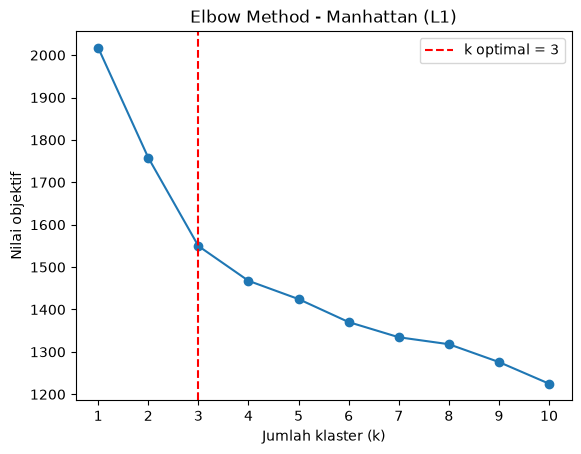

In [5]:
k_man = elbow('manhattan')

In [6]:
label_man, pusat_man, ring_man = jalankan('manhattan', k_man)
pd.DataFrame([ring_man]).T

,0
Model,KMeans-manhattan
Algoritma,KMeans
Metrik,Manhattan (L1)
Parameter,k=3
Jumlah Klaster,3
Noise (%),0.0
Silhouette (own),0.2604
Silhouette (Euclid),0.1992
Davies-Bouldin,1.8298
Calinski-Harabasz,60.79


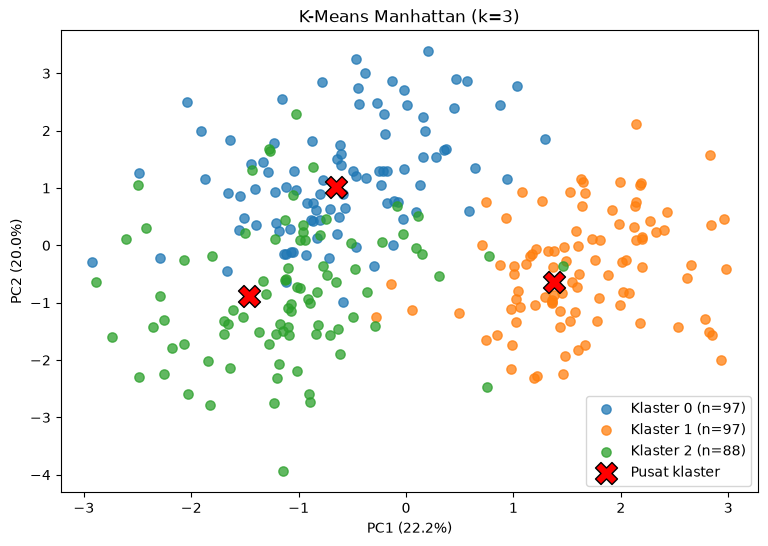

In [7]:
plot_pca(label_man, f'K-Means Manhattan (k={k_man})', pusat_man)

## 3. Tabel Hasil

Ringkasan evaluasi K-Means Manhattan. Perbandingan dengan metrik lain ada di `07_Perbandingan.ipynb`.

In [8]:
kolom = ['Metrik', 'Parameter', 'Silhouette (own)', 'Silhouette (Euclid)',
         'Davies-Bouldin', 'Calinski-Harabasz', 'Waktu (s)', 'Iterasi']
pd.DataFrame([ring_man])[kolom]

,Metrik,Parameter,Silhouette (own),Silhouette (Euclid),Davies-Bouldin,Calinski-Harabasz,Waktu (s),Iterasi
0,Manhattan (L1),k=3,0.2604,0.1992,1.8298,60.79,0.00515,7


## Kesimpulan

K-Means dijalankan dengan jarak Manhattan (Manhattan pakai median). Hasil disimpan di folder `Clustering_Stok` untuk dibandingkan di `07_Perbandingan.ipynb`.